In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import string
import matplotlib.pyplot as plt

In [ ]:
data= pd.read_csv("News.csv")

In [ ]:
data.columns


Index(['headline', 'category', 'authors', 'short_description'], dtype='object')

In [ ]:
data

,headline,category,authors,short_description
0,There Were 2 Mass Shootings In Texas Last Wee...,CRIME,Melissa Jeltsen,She left her husband. He killed their childre...
1,Will Smith Joins Diplo And Nicky Jam For The ...,ENTERTAINMENT,Andy McDonald,Of course it has a song.
2,Hugh Grant Marries For The First Time At Age ...,ENTERTAINMENT,Ron Dicker,The actor and his longtime girlfriend Anna Eb...
3,Jim Carrey Blasts 'Castrato' Adam Schiff And ...,ENTERTAINMENT,Ron Dicker,The actor gives Dems an ass-kicking for not f...
4,Julianna Margulies Uses Donald Trump Poop Bag...,ENTERTAINMENT,Ron Dicker,The Dietland actress said using the bags is a...
...,...,...,...,...
40864,Donald Trump Will Be President In Just Over A...,POLITICS,Sam Levine,It doesn't take long.
40865,Chris Pratt Bamboozles Us With The Best Worst...,COMEDY,Lee Moran,Shazam!
40866,U.S. Attorney General Tries To Defuse Tension...,POLITICS,Michael McLaughlin,Loretta Lynch is sending federal mediators to...
40867,Leftist Friends Gather As Castro Funeral Cort...,THE WORLDPOST,,On Sunday morning his ashes will be entombed


In [ ]:
data['category'].unique()

array([' CRIME  ', ' ENTERTAINMENT  ', ' WORLD NEWS  ', ' IMPACT  ',
       ' POLITICS  ', ' WEIRD NEWS  ', ' BLACK VOICES  ', ' WOMEN  ',
       ' COMEDY  ', ' QUEER VOICES  ', ' SPORTS  ', ' BUSINESS  ',
       ' TRAVEL  ', ' MEDIA  ', ' TECH  ', ' RELIGION  ', ' SCIENCE  ',
       ' LATINO VOICES  ', ' EDUCATION  ', ' COLLEGE  ', ' PARENTS  ',
       ' ARTS & CULTURE  ', ' STYLE  ', ' GREEN  ', ' TASTE  ',
       ' HEALTHY LIVING  ', ' THE WORLDPOST  ', ' GOOD NEWS  ',
       ' WORLDPOST  ', ' FIFTY  ', ' ARTS  '], dtype=object)

In [ ]:
data.shape

(40869, 4)

In [ ]:
data.isnull().sum()

,0
headline,0
category,0
authors,0
short_description,0


In [ ]:
data = data.drop(columns=['authors'])

In [ ]:
data.isnull().sum()

,0
headline,0
category,0
short_description,0


In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
40864,False
40865,False
40866,False
40867,False


In [ ]:
data.duplicated().sum()

np.int64(57)

In [ ]:

data = data.drop_duplicates()

In [ ]:
data.duplicated().sum()

np.int64(0)

Combine Text Columns

In [ ]:
data['text'] = data['headline'] + " " + data['short_description']

In [ ]:
data.columns

Index(['headline', 'category', 'short_description', 'text'], dtype='object')

Convert to Lowercase & Remove Punctuation

In [ ]:
import string

def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    return text

data['text'] = data['text'].apply(clean_text)


define features and target

In [ ]:
X = data['text']
y = data['category']

train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

convert text to numbers

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english')

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

Train Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_cv, y_train)

MultinomialNB()

evaluate model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = nb.predict(X_test_cv)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5594756829596962
                   precision    recall  f1-score   support

           ARTS         0.00      0.00      0.00         2
 ARTS & CULTURE         1.00      0.02      0.05       121
   BLACK VOICES         0.77      0.15      0.24       296
       BUSINESS         0.50      0.02      0.04        86
        COLLEGE         0.00      0.00      0.00         7
         COMEDY         0.70      0.28      0.40       309
          CRIME         0.59      0.20      0.30       133
      EDUCATION         0.00      0.00      0.00        53
  ENTERTAINMENT         0.48      0.83      0.61      1039
          FIFTY         0.00      0.00      0.00         1
      GOOD NEWS         0.00      0.00      0.00         1
          GREEN         0.67      0.05      0.09       125
 HEALTHY LIVING         0.73      0.31      0.43       307
         IMPACT         0.00      0.00      0.00        79
  LATINO VOICES         1.00      0.01      0.02        84
          MEDIA         0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


remove rare categories

In [ ]:
category_counts = data['category'].value_counts()

valid_categories = category_counts[category_counts > 500].index

data = data[data['category'].isin(valid_categories)]

In [ ]:
data['category'].unique()

array([' CRIME  ', ' ENTERTAINMENT  ', ' WORLD NEWS  ', ' POLITICS  ',
       ' WEIRD NEWS  ', ' BLACK VOICES  ', ' WOMEN  ', ' COMEDY  ',
       ' QUEER VOICES  ', ' SPORTS  ', ' BUSINESS  ', ' MEDIA  ',
       ' PARENTS  ', ' ARTS & CULTURE  ', ' STYLE  ', ' GREEN  ',
       ' TASTE  ', ' HEALTHY LIVING  ', ' THE WORLDPOST  '], dtype=object)

In [ ]:
data.category.value_counts()

,count
category,
POLITICS,14356
ENTERTAINMENT,5171
WORLD NEWS,2176
QUEER VOICES,1985
COMEDY,1697
HEALTHY LIVING,1577
BLACK VOICES,1431
PARENTS,1359
THE WORLDPOST,1312


TF-IDF

acccuracy checking

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# TF-IDF
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_df=0.7
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# Predict
y_pred = nb.predict(X_test_tfidf)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.40744824206786723
                   precision    recall  f1-score   support

           ARTS         0.00      0.00      0.00         2
 ARTS & CULTURE         0.00      0.00      0.00       121
   BLACK VOICES         0.00      0.00      0.00       296
       BUSINESS         0.00      0.00      0.00        86
        COLLEGE         0.00      0.00      0.00         7
         COMEDY         0.80      0.03      0.05       309
          CRIME         0.00      0.00      0.00       133
      EDUCATION         0.00      0.00      0.00        53
  ENTERTAINMENT         0.74      0.37      0.49      1039
          FIFTY         0.00      0.00      0.00         1
      GOOD NEWS         0.00      0.00      0.00         1
          GREEN         0.00      0.00      0.00       125
 HEALTHY LIVING         0.00      0.00      0.00       307
         IMPACT         0.00      0.00      0.00        79
  LATINO VOICES         0.00      0.00      0.00        84
          MEDIA         0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


keeping only 10 categories

In [ ]:
top_categories = data['category'].value_counts().nlargest(10).index

data_filtered = data[data['category'].isin(top_categories)]

In [ ]:
data_filtered['category'].value_counts()

,count
category,
POLITICS,14356
ENTERTAINMENT,5171
WORLD NEWS,2176
QUEER VOICES,1985
COMEDY,1697
HEALTHY LIVING,1577
BLACK VOICES,1431
PARENTS,1359
THE WORLDPOST,1312


In [ ]:
X = data_filtered['text']
y = data_filtered['category']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_df=0.8,
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred = nb.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6335759640700015
                   precision    recall  f1-score   support

   BLACK VOICES         0.90      0.07      0.12       286
         COMEDY         0.84      0.21      0.33       340
  ENTERTAINMENT         0.60      0.80      0.69      1034
 HEALTHY LIVING         0.89      0.16      0.27       315
        PARENTS         0.81      0.21      0.33       272
       POLITICS         0.62      0.98      0.76      2872
   QUEER VOICES         0.91      0.25      0.39       397
  THE WORLDPOST         0.81      0.05      0.09       262
          WOMEN         0.85      0.05      0.09       244
     WORLD NEWS         0.65      0.27      0.38       435

         accuracy                           0.63      6457
        macro avg       0.79      0.30      0.35      6457
     weighted avg       0.70      0.63      0.56      6457



tune naive bayes

In [ ]:
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_tfidf, y_train)

MultinomialNB(alpha=0.5)

In [ ]:
y_pred = nb.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.679572556914976


In [ ]:
for a in [0.1, 0.5, 1.0, 2.0]:
    nb = MultinomialNB(alpha=a)
    nb.fit(X_train_tfidf, y_train)
    y_pred = nb.predict(X_test_tfidf)
    print("Alpha:", a, "Accuracy:", accuracy_score(y_test, y_pred))

Alpha: 0.1 Accuracy: 0.716122038098188
Alpha: 0.5 Accuracy: 0.679572556914976
Alpha: 1.0 Accuracy: 0.6335759640700015
Alpha: 2.0 Accuracy: 0.5844819575654329


In [ ]:
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)

MultinomialNB(alpha=0.1)

In [ ]:
y_pred = nb.predict(X_test_tfidf)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.716122038098188


# ADa boosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Weak learner
base_model = DecisionTreeClassifier(max_depth=1)

# AdaBoost
ada = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1
)

ada.fit(X_train_tfidf, y_train)

y_pred_ada = ada.predict(X_test_tfidf)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))

AdaBoost Accuracy: 0.44695679107944863


# Hierarchical Clustering

reduce features

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2)
X_reduced = svd.fit_transform(X_train_tfidf)

apply hierarchical clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)

clusters = hc.fit_predict(X_reduced)

visualization

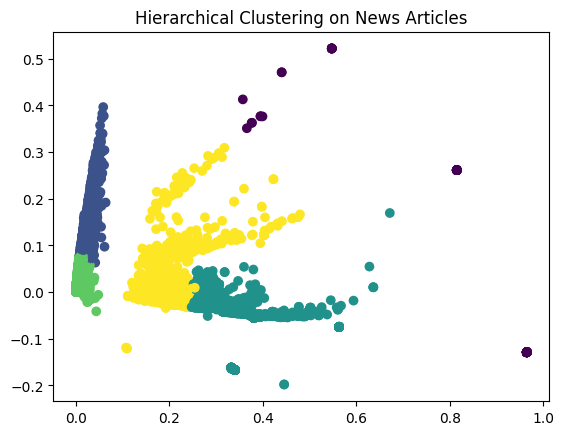

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_reduced[:,0], X_reduced[:,1], c=clusters)
plt.title("Hierarchical Clustering on News Articles")
plt.show()

# DBSCAN

USING SAME REDUCED DATA

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)

db_clusters = db.fit_predict(X_reduced)

visualization

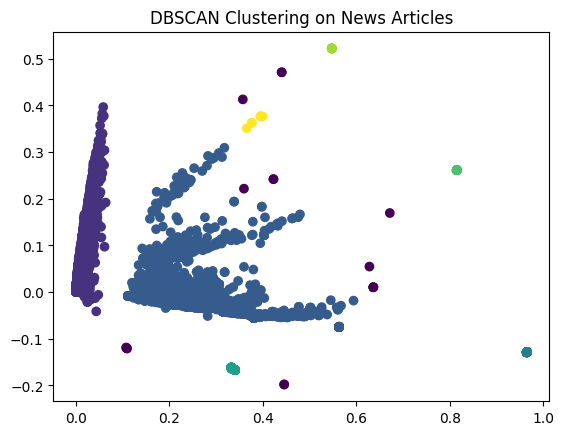

In [ ]:
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=db_clusters)
plt.title("DBSCAN Clustering on News Articles")
plt.show()

In [ ]:
import numpy as np
print(np.unique(db_clusters))

[-1  0  1  2  3  4  5  6]


In [ ]:
db = DBSCAN(eps=0.05, min_samples=5)

In [ ]:
db_clusters = db.fit_predict(X_reduced)